## NER 기반 그래프 구조 추출하기

NER 모델 로딩

In [2]:
# install: python -m spacy download en_core_web_sm
import networkx as nx
import spacy # spaCy: 산업용 NLP 라이브러리 (Explosion AI 개발)

# NER 모델 로드
nlp = spacy.load("en_core_web_sm") # en_core_web_sm: CNN 기반 Tok2Vec, 13MB 소형 모델
ruler = nlp.add_pipe("entity_ruler", before="ner") # 학습 모델에 없는 PET 엔티티 EntityRuler로 추가
patterns = [
    {"label": "PET", "pattern": "Coco"},
]
ruler.add_patterns(patterns)

NER 분석할 예제 데이터 정의

In [3]:
# 예시 스토리
story_text = """
Alice works at Google in New York. 
She has a cat named Coco. 
Yesterday, Alice met her friend Bob at Central Park.
Bob works for Microsoft and lives in Seattle.
They discussed the new project with their colleague Charlie from Amazon.
"""

print(story_text)


Alice works at Google in New York. 
She has a cat named Coco. 
Yesterday, Alice met her friend Bob at Central Park.
Bob works for Microsoft and lives in Seattle.
They discussed the new project with their colleague Charlie from Amazon.



spaCy로 NER 및 구문 분석

In [4]:
doc = nlp(story_text)
entities = [(ent.text, ent.label_) for ent in doc.ents] # 개체명 추출

print("\n개체명 인식:")
for word, label in entities:
    print(f"  {word:<15} ({label})")

classified = {'PERSON': [], 'ORG': [], 'GPE': [], 'LOC': [], 'PET': []}
for word, label in entities:
    if label in classified and word not in classified[label]:
        classified[label].append(word)

print("\n분류:")
print(f"  사람: {', '.join(classified['PERSON'])}")
print(f"  조직: {', '.join(classified['ORG'])}")
print(f"  장소: {', '.join(classified['GPE'] + classified['LOC'])}")
print(f"  애완동물: {', '.join(classified['PET'])}")




개체명 인식:
  Alice           (PERSON)
  Google          (ORG)
  New York        (GPE)
  Coco            (PET)
  Yesterday       (DATE)
  Alice           (PERSON)
  Bob             (PERSON)
  Central Park    (LOC)
  Bob             (PERSON)
  Microsoft       (ORG)
  Seattle         (GPE)
  Charlie         (PERSON)
  Amazon          (ORG)

분류:
  사람: Alice, Bob, Charlie
  조직: Google, Microsoft, Amazon
  장소: New York, Seattle, Central Park
  애완동물: Coco


Dependency Parsing으로 Subject-Verb-Object Triple 자동 추출

In [5]:
def extract_triples_auto(doc):
    triples = []
    
    entity_map = {}
    last_person = None
    for token in doc:
        if token.ent_type_ == "PERSON":
            last_person = token.text
        elif token.pos_ == "PRON" and token.text.lower() in ("he", "she") and last_person:
            entity_map[token.i] = last_person
    
    for sent in doc.sents:
        verb = next((t for t in sent if t.dep_ == "ROOT" and t.pos_ == "VERB"), None)
        if not verb:
            continue
        
        subject_token = next((c for c in verb.children 
                             if c.dep_ in ("nsubj", "nsubjpass")), None)
        if not subject_token:
            continue
        
        if subject_token.i in entity_map:
            subject = entity_map[subject_token.i]
        elif subject_token.ent_type_ or subject_token.pos_ == "PROPN":
            subject = subject_token.text
        else:
            continue
        
        for child in verb.children:
            if child.dep_ == "prep":
                for pobj in child.children:
                    if pobj.dep_ == "pobj" and (pobj.ent_type_ or pobj.pos_ == "PROPN"):
                        relation = f"{verb.lemma_}_{child.text}"
                        triples.append((subject, relation, pobj.text))
                continue
            
            if child.dep_ != "dobj":
                continue
            
            if child.ent_type_ or child.pos_ == "PROPN":
                triples.append((subject, verb.lemma_, child.text))
            
            friend_token = next((d for d in child.subtree if d.text.lower() == "friend"), None)
            if friend_token:
                for friend in friend_token.children:
                    if friend.ent_type_ == "PERSON":
                        triples.append((subject, "has_friend", friend.text))
            
            named_token = next((d for d in child.subtree if d.text.lower() == "named"), None)
            if named_token:
                for pet in named_token.children:
                    if pet.ent_type_ == "PET" or pet.pos_ == "PROPN":
                        triples.append((subject, "has_pet", pet.text))
                        break
    
    return triples

triples = extract_triples_auto(doc)

print("\n트리플 구조 자동 추출:")
for s, p, o in triples:
    print(f"  ({s}) --[{p}]--> ({o})")



트리플 구조 자동 추출:
  (Alice) --[work_at]--> (Google)
  (Alice) --[work_in]--> (York)
  (Alice) --[has_pet]--> (Coco)
  (Alice) --[has_friend]--> (Bob)
  (Alice) --[meet_at]--> (Park)
  (Bob) --[work_for]--> (Microsoft)


그래프 구조 생성 및 시각화


지식 그래프 구조:
  [Alice]
    └─ work_at → [Google]
    └─ work_in → [York]
    └─ has_pet → [Coco]
    └─ has_friend → [Bob]
    └─ meet_at → [Park]
  [Bob]
    └─ work_for → [Microsoft]


C:\Users\MAC\AppData\Local\Temp\ipykernel_7212\2489954475.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


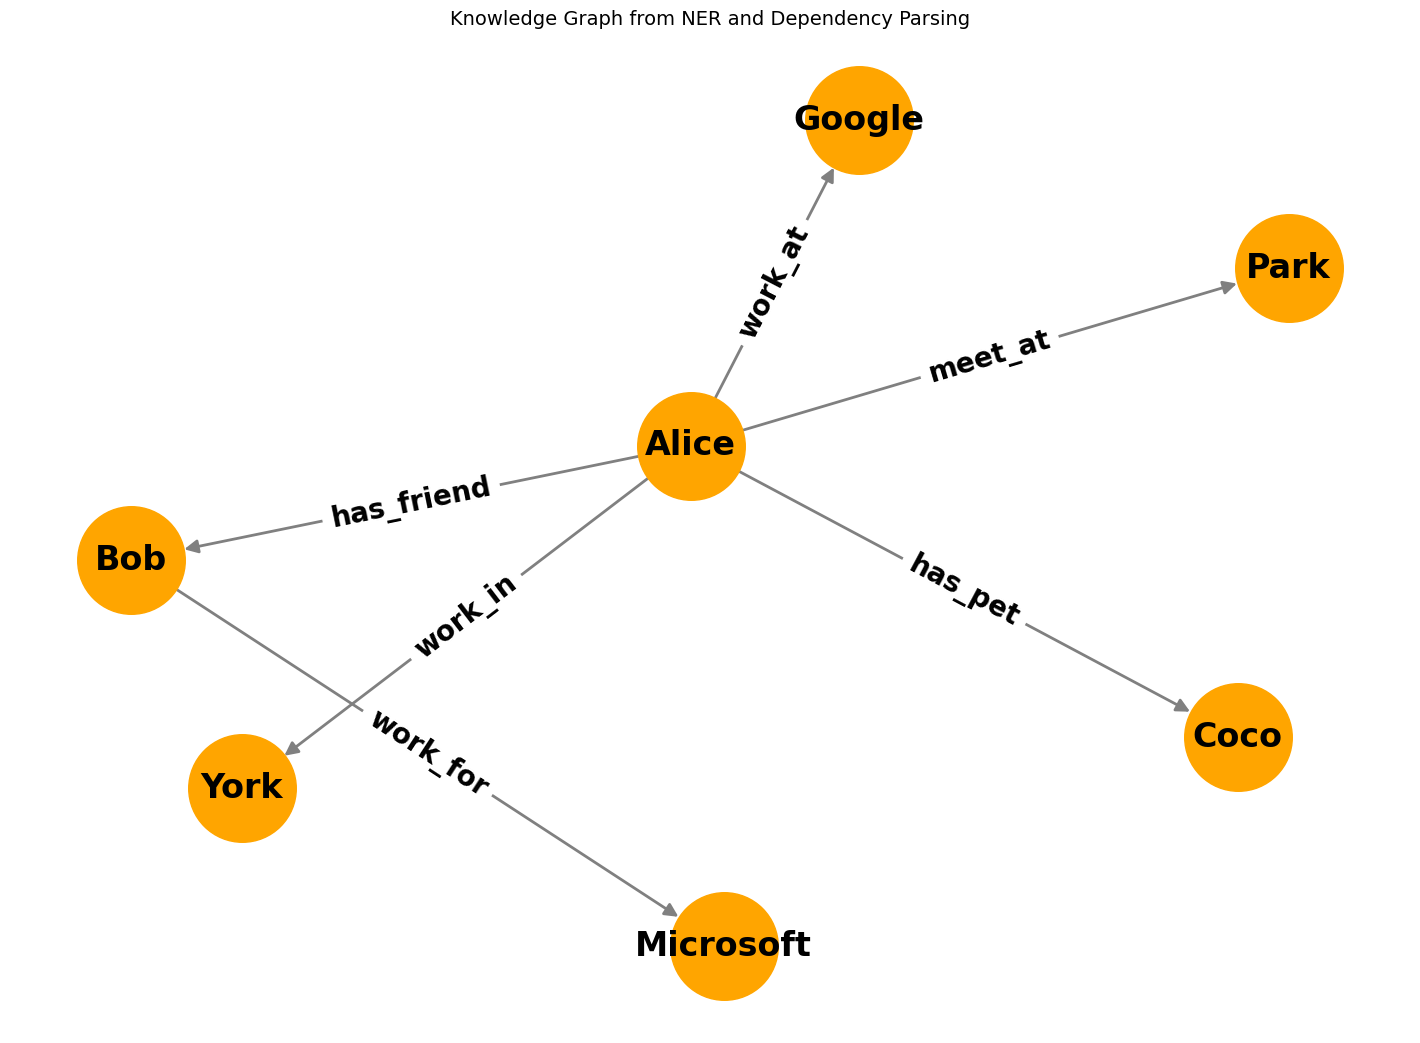

In [6]:
G = nx.DiGraph() # 라이브러리 이용, 관계를 시각적인 그래프로 작성
for s, p, o in triples:
    G.add_edge(s, o, relation=p)

print("\n지식 그래프 구조:")
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if neighbors:
        print(f"  [{node}]")
        for neighbor in neighbors:
            rel = G[node][neighbor]['relation']
            print(f"    └─ {rel} → [{neighbor}]")

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50)
nx.draw(G, pos, with_labels=True, node_color='orange', node_size=6000, font_size=24, font_weight='bold', arrows=True, arrowsize=20, edge_color='gray', width=2)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=20, font_weight='bold')
plt.title("Knowledge Graph from NER and Dependency Parsing", fontsize=14)
plt.tight_layout()
plt.show()